# Week 4 — 문서 데이터 분석
**대상 문서**: `registration_of_real_estatee_manual.pdf` (부동산 등기 업무 매뉴얼)  
**분석 목표**:
1. 문서의 구조적 특성 파악 (표·이미지·헤더·각주·메타데이터)
2. 노이즈 요소 식별 (페이지 번호·머리말/꼬리말·중복 문장)
3. 문서 길이 분포 확인 (토큰 수 통계 + 시각화)


In [1]:
import re
import fitz          # PyMuPDF
import tiktoken
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from collections import Counter
from pathlib import Path

PDF_PATH = "../data/registration_of_real_estatee_manual.pdf"

# 한글 폰트 설정 (Windows)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# GPT 계열 토크나이저 (cl100k_base = GPT-4 / text-embedding-3)
enc = tiktoken.get_encoding("cl100k_base")

doc = fitz.open(PDF_PATH)
print(f"총 페이지 수: {len(doc)}")

총 페이지 수: 226


---
## 1. 문서 구조적 특성 파악

### 1-1. 메타데이터

In [2]:
meta = doc.metadata
print("=" * 50)
for key, val in meta.items():
    print(f"  {key:20s}: {val if val else '(없음)'}")
print("=" * 50)

  format              : PDF 1.4
  title               : 찾기쉬운 생활법령 - 부동산등기
  author              : 법제처 법제정보담당관
  subject             : (없음)
  keywords            : (없음)
  creator             : PD4ML. HTML to PDF Converter for Java (380)
  producer            : PD4ML. HTML to PDF Converter for Java (380)
  creationDate        : D:20260426002818+09'00'
  modDate             : (없음)
  trapped             : (없음)
  encryption          : (없음)


### 1-2. 이미지 · 표 · 헤더 · 각주 탐지

In [3]:
structure = {
    "pages_with_images":  [],
    "pages_with_tables":  [],
    "pages_with_headers": [],
    "pages_with_footnotes": [],
}

# 헤더/각주 판별을 위한 폰트 크기 기준
HEADER_FONT_SIZE   = 14   # 이 크기 이상이면 헤더 후보
FOOTNOTE_FONT_SIZE = 8    # 이 크기 이하이면 각주 후보

for page_num, page in enumerate(doc, start=1):
    # 이미지 탐지
    if page.get_images(full=False):
        structure["pages_with_images"].append(page_num)

    # 표 탐지 (PyMuPDF 1.23+)
    try:
        tables = page.find_tables()
        if tables.tables:
            structure["pages_with_tables"].append(page_num)
    except AttributeError:
        pass  # 구버전 PyMuPDF

    # 헤더 / 각주: 텍스트 블록의 폰트 크기로 판별
    blocks = page.get_text("dict")["blocks"]
    for block in blocks:
        if block["type"] != 0:   # 0 = text block
            continue
        for line in block["lines"]:
            for span in line["spans"]:
                fs = span["size"]
                if fs >= HEADER_FONT_SIZE and page_num not in structure["pages_with_headers"]:
                    structure["pages_with_headers"].append(page_num)
                if fs <= FOOTNOTE_FONT_SIZE and page_num not in structure["pages_with_footnotes"]:
                    structure["pages_with_footnotes"].append(page_num)

total = len(doc)
print(f"{'항목':<25} {'건수':>6}  {'비율':>7}")
print("-" * 42)
for label, pages in structure.items():
    print(f"  {label:<23} {len(pages):>4}페이지  ({len(pages)/total*100:5.1f}%)")

Consider using the pymupdf_layout package for a greatly improved page layout analysis.
항목                            건수       비율
------------------------------------------
  pages_with_images         64페이지  ( 28.3%)
  pages_with_tables         15페이지  (  6.6%)
  pages_with_headers         1페이지  (  0.4%)
  pages_with_footnotes       0페이지  (  0.0%)


In [4]:
# 이미지가 있는 페이지 샘플 확인
print("이미지 포함 페이지 (최대 10개):", structure["pages_with_images"][:10])
print("표 포함 페이지   (최대 10개):", structure["pages_with_tables"][:10])
print("헤더 감지 페이지 (최대 10개):", structure["pages_with_headers"][:10])
print("각주 감지 페이지 (최대 10개):", structure["pages_with_footnotes"][:10])

이미지 포함 페이지 (최대 10개): [1, 8, 13, 15, 16, 17, 19, 24, 26, 28]
표 포함 페이지   (최대 10개): [6, 14, 48, 50, 59, 60, 70, 85, 86, 96]
헤더 감지 페이지 (최대 10개): [1]
각주 감지 페이지 (최대 10개): []


In [5]:
# 폰트 크기 분포 — 어떤 크기가 주류인지 파악
all_font_sizes = []
for page in doc:
    for block in page.get_text("dict")["blocks"]:
        if block["type"] != 0:
            continue
        for line in block["lines"]:
            for span in line["spans"]:
                if span["text"].strip():
                    all_font_sizes.append(round(span["size"], 1))

size_counter = Counter(all_font_sizes).most_common(15)
print("폰트 크기 Top 15:")
print(f"  {'크기':>6}  {'출현 횟수':>10}")
for sz, cnt in size_counter:
    bar = "█" * (cnt // max(1, max(c for _, c in size_counter) // 30))
    print(f"  {sz:>6.1f}  {cnt:>10,}  {bar}")

폰트 크기 Top 15:
      크기       출현 횟수
     9.3      42,176  ██████████████████████████████
    10.6         450  
    11.3         242  
     9.9           3  
    39.8           1  


---
## 2. 노이즈 요소 식별

In [6]:
# 페이지별 전체 텍스트 수집
page_texts = [page.get_text("text") for page in doc]

# --- 2-1. 페이지 번호 패턴 ---
# 페이지 끝이나 시작에 단독으로 등장하는 숫자
PAGE_NUM_RE = re.compile(r"(?m)^\s*\d{1,4}\s*$")

pages_with_page_number = []
for i, text in enumerate(page_texts, 1):
    if PAGE_NUM_RE.search(text):
        pages_with_page_number.append(i)

print(f"페이지 번호 패턴 감지: {len(pages_with_page_number)}/{len(doc)} 페이지")
print(f"  샘플: {pages_with_page_number[:10]}")

페이지 번호 패턴 감지: 5/226 페이지
  샘플: [3, 4, 5, 43, 62]


In [7]:
# --- 2-2. 머리말/꼬리말 (반복 텍스트) ---
# 각 페이지의 첫 줄 / 마지막 줄을 모아 2회 이상 등장하면 반복 요소로 판단

first_lines, last_lines = [], []
for text in page_texts:
    lines = [l.strip() for l in text.splitlines() if l.strip()]
    if lines:
        first_lines.append(lines[0])
        last_lines.append(lines[-1])

def repeated_elements(line_list, threshold=2):
    counter = Counter(line_list)
    return {text: cnt for text, cnt in counter.items() if cnt >= threshold and len(text) > 1}

repeated_headers = repeated_elements(first_lines)
repeated_footers = repeated_elements(last_lines)

print(f"반복 머리말 후보 ({len(repeated_headers)}개):")
for text, cnt in sorted(repeated_headers.items(), key=lambda x: -x[1]):
    print(f"  [{cnt:3d}회] {repr(text[:60])}")

print(f"\n반복 꼬리말 후보 ({len(repeated_footers)}개):")
for text, cnt in sorted(repeated_footers.items(), key=lambda x: -x[1]):
    print(f"  [{cnt:3d}회] {repr(text[:60])}")

반복 머리말 후보 (23개):
  [ 15회] '<출처 : 인터넷등기소홈페이지, 등기신청, 신청관리, 전자신청이용안내및절차보기>'
  [ 13회] '전자표준양식을'
  [  8회] '※ 관할등기소는 <대법원인터넷등기소-등기소소개-등기소찾기> 에서확인하실수있습니다.'
  [  8회] '최초의등기신청전에사용자등록을해야합니다(「부동산등기규칙」제68조제1항).'
  [  5회] '<출처 : 인터넷등기소홈페이지, 인터넷등기소간편길잡이-e-Form 신청-부동산(통합전자등기)-e-Form'
  [  4회] '찾기쉬운생활법령'
  [  4회] '<신청서작성시참조자료: 등기사항증명서예시>'
  [  3회] '67조제4항제1호참조).'
  [  3회] '등기'
  [  2회] '부동산등기'
  [  2회] '<출처: 위텍스홈페이지(www.wetax.go.kr), 지방세정보-지방세미리계산해보기>'
  [  2회] '"지방교육세"란지방교육의질적향상에필요한지방교육재정의확충에소요되는재원을확보하기위해「'
  [  2회] '√대법원등기'
  [  2회] '과세문서'
  [  2회] '말합니다.'
  [  2회] '등기종류'
  [  2회] '등기권리자의주민등록등(초)본또는주민등록증사본및등기의무자의인감증명서'
  [  2회] '인증서(범용, 용도제한용불문)의발급'
  [  2회] '신청절차>'
  [  2회] '지방세특례제한법」에따라감면받은경우제외)를내지않아도됩니다.'
  [  2회] '※ 시, 군, 구청세무과를방문해등록면허세납부고지서를발부받고세금을은행에서납부하면됩니다.'
  [  2회] '등록면허세납부고지서(지방교육세포함)'
  [  2회] '사용자등록신청을하면등기소에서접근번호를부여해줍니다.'

반복 꼬리말 후보 (0개):


In [8]:
# --- 2-3. 중복 문장 탐지 ---
# 전체 문서에서 문장 단위로 분리 후 2회 이상 등장하는 문장 식별

full_text = "\n".join(page_texts)
# 마침표/줄바꿈 기준으로 문장 분리 (간이 방식)
sentences = re.split(r"(?<=[.。!?\n])\s+", full_text)
sentences = [s.strip() for s in sentences if len(s.strip()) > 15]  # 짧은 토막 제거

sent_counter = Counter(sentences)
duplicates = {s: c for s, c in sent_counter.items() if c >= 2}

print(f"전체 문장 수: {len(sentences):,}")
print(f"중복 문장 수: {len(duplicates)}개\n")
print("중복 Top 5:")
for sent, cnt in sorted(duplicates.items(), key=lambda x: -x[1])[:5]:
    print(f"  [{cnt}회] {sent[:80]}..." if len(sent) > 80 else f"  [{cnt}회] {sent}")

전체 문장 수: 1,957
중복 문장 수: 105개

중복 Top 5:
  [20회] 본인또는자격자대리인이직접등기과(소)를
방문해사용자등록신청을해야합니다(전국등기소어느
곳에서나가능)[「부동산등기규칙」제68조제2항].
  [20회] 유효기간의연장은전자문서로신청할수있습니다(「부동산등기규칙」제69조제4항).
  [19회] 다만, 법인이아닌사단이나재단은전자신청을할수없으며, 외국인의경우에는다음중어느하나에
해당하는요건을갖추어야합니다(「부동산등기규칙」제67조제1항단서).
  [19회] 유효기간의연장
유효기간만료일3개월전부터만료일까지그유효기간의연장을신청할수있으며, 그연장기간은위의
유효기간에따른기간으로합니다(「부동산등기규칙」제69...
  [19회] ※ 제출후접수상황확인
등기소에
신청서를
제출한
후
<대법원인터넷등기소-등기열람/발급-등기신청사건
처리현황>
에
부동산의
소재지번을입력하면접수상황...


In [9]:
# --- 2-4. 노이즈 종합 요약 ---
noise_summary = {
    "페이지 번호 패턴": len(pages_with_page_number),
    "반복 머리말": len(repeated_headers),
    "반복 꼬리말": len(repeated_footers),
    "중복 문장": len(duplicates),
}
print("노이즈 요소 요약")
print("=" * 40)
for k, v in noise_summary.items():
    print(f"  {k:<18}: {v}건")

노이즈 요소 요약
  페이지 번호 패턴         : 5건
  반복 머리말            : 23건
  반복 꼬리말            : 0건
  중복 문장             : 105건


---
## 3. 문서 길이 분포 확인

In [10]:
# 페이지별 토큰 수 계산
token_counts = [len(enc.encode(text)) for text in page_texts]

stats = {
    "총 페이지": len(token_counts),
    "총 토큰 수": sum(token_counts),
    "최솟값": int(np.min(token_counts)),
    "최댓값": int(np.max(token_counts)),
    "평균": round(float(np.mean(token_counts)), 1),
    "중앙값": float(np.median(token_counts)),
    "표준편차": round(float(np.std(token_counts)), 1),
    "p25": float(np.percentile(token_counts, 25)),
    "p75": float(np.percentile(token_counts, 75)),
}

print("페이지별 토큰 수 통계 (cl100k_base)")
print("=" * 40)
for k, v in stats.items():
    print(f"  {k:<12}: {v:,}")

페이지별 토큰 수 통계 (cl100k_base)
  총 페이지       : 226
  총 토큰 수      : 208,783
  최솟값         : 7
  최댓값         : 3,928
  평균          : 923.8
  중앙값         : 984.5
  표준편차        : 520.0
  p25         : 594.75
  p75         : 1,186.25


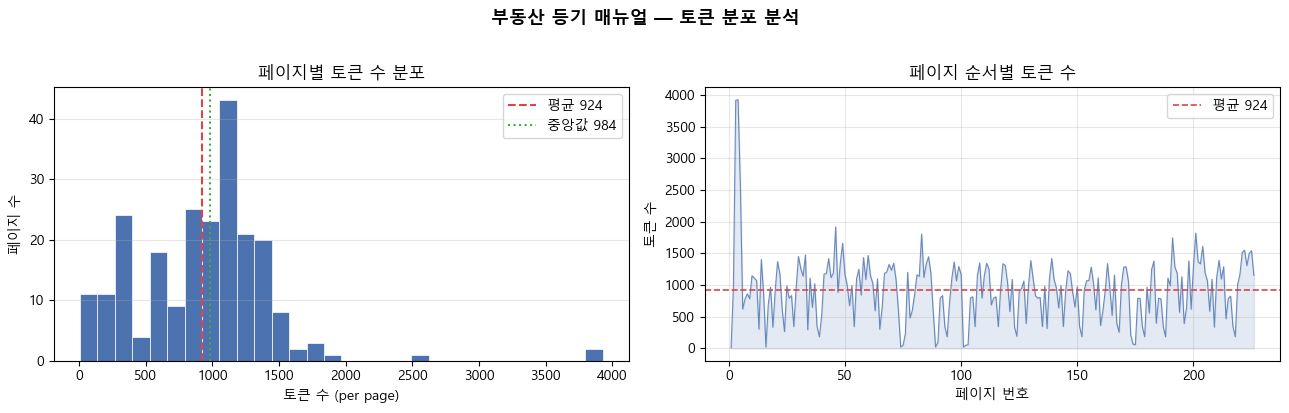

저장 완료: ../results/token_distribution.png


In [11]:
# 시각화: 페이지별 토큰 수 분포 히스토그램
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- 히스토그램 ---
ax = axes[0]
ax.hist(token_counts, bins=30, color="#4C72B0", edgecolor="white", linewidth=0.5)
ax.axvline(stats["평균"],  color="#DD4444", linestyle="--", linewidth=1.5, label=f"평균 {stats['평균']:.0f}")
ax.axvline(stats["중앙값"], color="#44AA44", linestyle=":",  linewidth=1.5, label=f"중앙값 {stats['중앙값']:.0f}")
ax.set_xlabel("토큰 수 (per page)")
ax.set_ylabel("페이지 수")
ax.set_title("페이지별 토큰 수 분포")
ax.legend()
ax.grid(axis="y", alpha=0.3)

# --- 페이지 순서별 토큰 수 라인 차트 ---
ax2 = axes[1]
ax2.plot(range(1, len(token_counts) + 1), token_counts, color="#4C72B0", linewidth=0.8, alpha=0.8)
ax2.axhline(stats["평균"], color="#DD4444", linestyle="--", linewidth=1.2, label=f"평균 {stats['평균']:.0f}")
ax2.fill_between(
    range(1, len(token_counts) + 1), token_counts,
    alpha=0.15, color="#4C72B0"
)
ax2.set_xlabel("페이지 번호")
ax2.set_ylabel("토큰 수")
ax2.set_title("페이지 순서별 토큰 수")
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle("부동산 등기 매뉴얼 — 토큰 분포 분석", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../results/token_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("저장 완료: ../results/token_distribution.png")

---
## 4. 종합 분석 결과 및 RAG 설계 시사점

In [12]:
total_pages = len(doc)

print("="*60)
print("  종합 분석 결과")
print("="*60)

print("\n[구조]")
print(f"  총 페이지      : {total_pages}")
print(f"  이미지 포함    : {len(structure['pages_with_images'])}페이지  "
      f"→ 이미지 내 텍스트 손실 가능 (OCR 고려)")
print(f"  표 포함        : {len(structure['pages_with_tables'])}페이지  "
      f"→ 표 구조 붕괴 방지 위해 Camelot/pdfplumber 검토")
print(f"  헤더 감지      : {len(structure['pages_with_headers'])}페이지  "
      f"→ MarkdownHeaderTextSplitter 또는 구조 인식 Chunking 적용 가능")
print(f"  각주 감지      : {len(structure['pages_with_footnotes'])}페이지  "
      f"→ 법률 근거 포함 가능, 제거 여부 신중히 결정 필요")

print("\n[노이즈]")
print(f"  페이지 번호    : {len(pages_with_page_number)}페이지 감지  → 전처리 시 정규식으로 제거")
print(f"  반복 머리말    : {len(repeated_headers)}종  → 청크에 불필요한 반복 텍스트 유입 방지")
print(f"  반복 꼬리말    : {len(repeated_footers)}종  → 동일")
print(f"  중복 문장      : {len(duplicates)}건  → Dedup 전처리 또는 MMR 검색으로 완화")

print("\n[토큰 분포]")
print(f"  평균 토큰/페이지: {stats['평균']:>7,.1f}")
print(f"  최솟값         : {stats['최솟값']:>7,}  → 목차·표지 등 정보 밀도 낮은 페이지")
print(f"  최댓값         : {stats['최댓값']:>7,}  → chunk_size=1200 기준으로 한 페이지가 여러 청크로 분리됨")
print(f"  총 토큰 수     : {stats['총 토큰 수']:>7,}")

print("\n[RAG 설계 권고]")
print("  1. 전처리: 페이지 번호 · 반복 머리말/꼬리말 제거 후 임베딩")
print("  2. Chunking: chunk_size=1200은 평균 토큰과 적절히 매칭됨. 유지")
print("  3. 표 처리: pdfplumber로 표를 별도 청크로 구성하는 방식 검토")
print("  4. 이미지: 텍스트 손실 여부 확인 후 필요시 OCR 파이프라인 추가")
print("="*60)

  종합 분석 결과

[구조]
  총 페이지      : 226
  이미지 포함    : 64페이지  → 이미지 내 텍스트 손실 가능 (OCR 고려)
  표 포함        : 15페이지  → 표 구조 붕괴 방지 위해 Camelot/pdfplumber 검토
  헤더 감지      : 1페이지  → MarkdownHeaderTextSplitter 또는 구조 인식 Chunking 적용 가능
  각주 감지      : 0페이지  → 법률 근거 포함 가능, 제거 여부 신중히 결정 필요

[노이즈]
  페이지 번호    : 5페이지 감지  → 전처리 시 정규식으로 제거
  반복 머리말    : 23종  → 청크에 불필요한 반복 텍스트 유입 방지
  반복 꼬리말    : 0종  → 동일
  중복 문장      : 105건  → Dedup 전처리 또는 MMR 검색으로 완화

[토큰 분포]
  평균 토큰/페이지:   923.8
  최솟값         :       7  → 목차·표지 등 정보 밀도 낮은 페이지
  최댓값         :   3,928  → chunk_size=1200 기준으로 한 페이지가 여러 청크로 분리됨
  총 토큰 수     : 208,783

[RAG 설계 권고]
  1. 전처리: 페이지 번호 · 반복 머리말/꼬리말 제거 후 임베딩
  2. Chunking: chunk_size=1200은 평균 토큰과 적절히 매칭됨. 유지
  3. 표 처리: pdfplumber로 표를 별도 청크로 구성하는 방식 검토
  4. 이미지: 텍스트 손실 여부 확인 후 필요시 OCR 파이프라인 추가
